In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('✅ All libraries imported!')
print(f'   TensorFlow version: {tf.__version__}')

✅ All libraries imported!
   TensorFlow version: 2.18.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('✅ All libraries imported!')
print(f'   TensorFlow version: {tf.__version__}')

In [3]:
# Generate 1 year of hourly electricity data
n_days = 365
hours_per_day = 24
n_hours = n_days * hours_per_day

timestamps = pd.date_range(start='2024-01-01', periods=n_hours, freq='h')

# Day type logic
day_of_week = timestamps.dayofweek  # 0=Mon, 6=Sun
is_weekend = (day_of_week >= 5).astype(int)

# Event schedule: random events on ~40% of days (mostly evenings)
np.random.seed(42)
day_index = np.arange(n_days)
event_days = np.random.choice(day_index, size=int(n_days * 0.4), replace=False)
event_day_set = set(event_days)

is_event_day = np.array([(d // 24) in event_day_set for d in range(n_hours)]).astype(int)

# Electricity consumption simulation (kWh per hour)
electricity = []
for i, ts in enumerate(timestamps):
    h = ts.hour
    day = i // 24
    is_ev = day in event_day_set
    is_wknd = ts.dayofweek >= 5

    # Base load by hour (facility always on)
    base = 30 + 10 * np.sin(np.pi * h / 12)  # sinusoidal daily pattern

    # Event boost: 6 PM – 11 PM spike
    event_boost = 80 * np.exp(-0.5 * ((h - 20) / 2) ** 2) if is_ev else 0

    # Post-event drop: midnight – 3 AM still elevated
    post_event = 25 * np.exp(-0.5 * ((h - 1) / 1.5) ** 2) if is_ev else 0

    # Weekend base is higher (sports leagues)
    weekend_adj = 15 if is_wknd else 0

    # Noise
    noise = np.random.normal(0, 4)

    kwh = max(10, base + event_boost + post_event + weekend_adj + noise)
    electricity.append(kwh)

df = pd.DataFrame({
    'timestamp': timestamps,
    'electricity_kwh': electricity,
    'hour': timestamps.hour,
    'day_of_week': day_of_week,
    'is_weekend': is_weekend,
    'is_event_day': is_event_day,
    'month': timestamps.month
})

# Day type label
def day_type(row):
    if row['is_event_day'] and row['is_weekend']: return 'Weekend Event'
    elif row['is_event_day']: return 'Weekday Event'
    elif row['is_weekend']: return 'Weekend Normal'
    else: return 'Weekday Normal'

df['day_type'] = df.apply(day_type, axis=1)

print('📊 Dataset shape:', df.shape)
print('\n📅 Day type distribution:')
print(df['day_type'].value_counts())
print(f'\n⚡ Electricity stats (kWh):')
print(df['electricity_kwh'].describe().round(2))
df.head()

📊 Dataset shape: (8760, 8)

📅 Day type distribution:
day_type
Weekday Normal    3768
Weekday Event     2496
Weekend Normal    1488
Weekend Event     1008
Name: count, dtype: int64

⚡ Electricity stats (kWh):
count    8760.00
mean       42.07
std        19.00
min        10.00
25%        29.57
50%        38.30
75%        49.35
max       122.74
Name: electricity_kwh, dtype: float64


,timestamp,electricity_kwh,hour,day_of_week,is_weekend,is_event_day,month,day_type
0,2024-01-01 00:00:00,45.285373,0,0,0,1,1,Weekday Event
1,2024-01-01 01:00:00,59.568173,1,0,0,1,1,Weekday Event
2,2024-01-01 02:00:00,54.357197,2,0,0,1,1,Weekday Event
3,2024-01-01 03:00:00,44.600174,3,0,0,1,1,Weekday Event
4,2024-01-01 04:00:00,42.317041,4,0,0,1,1,Weekday Event


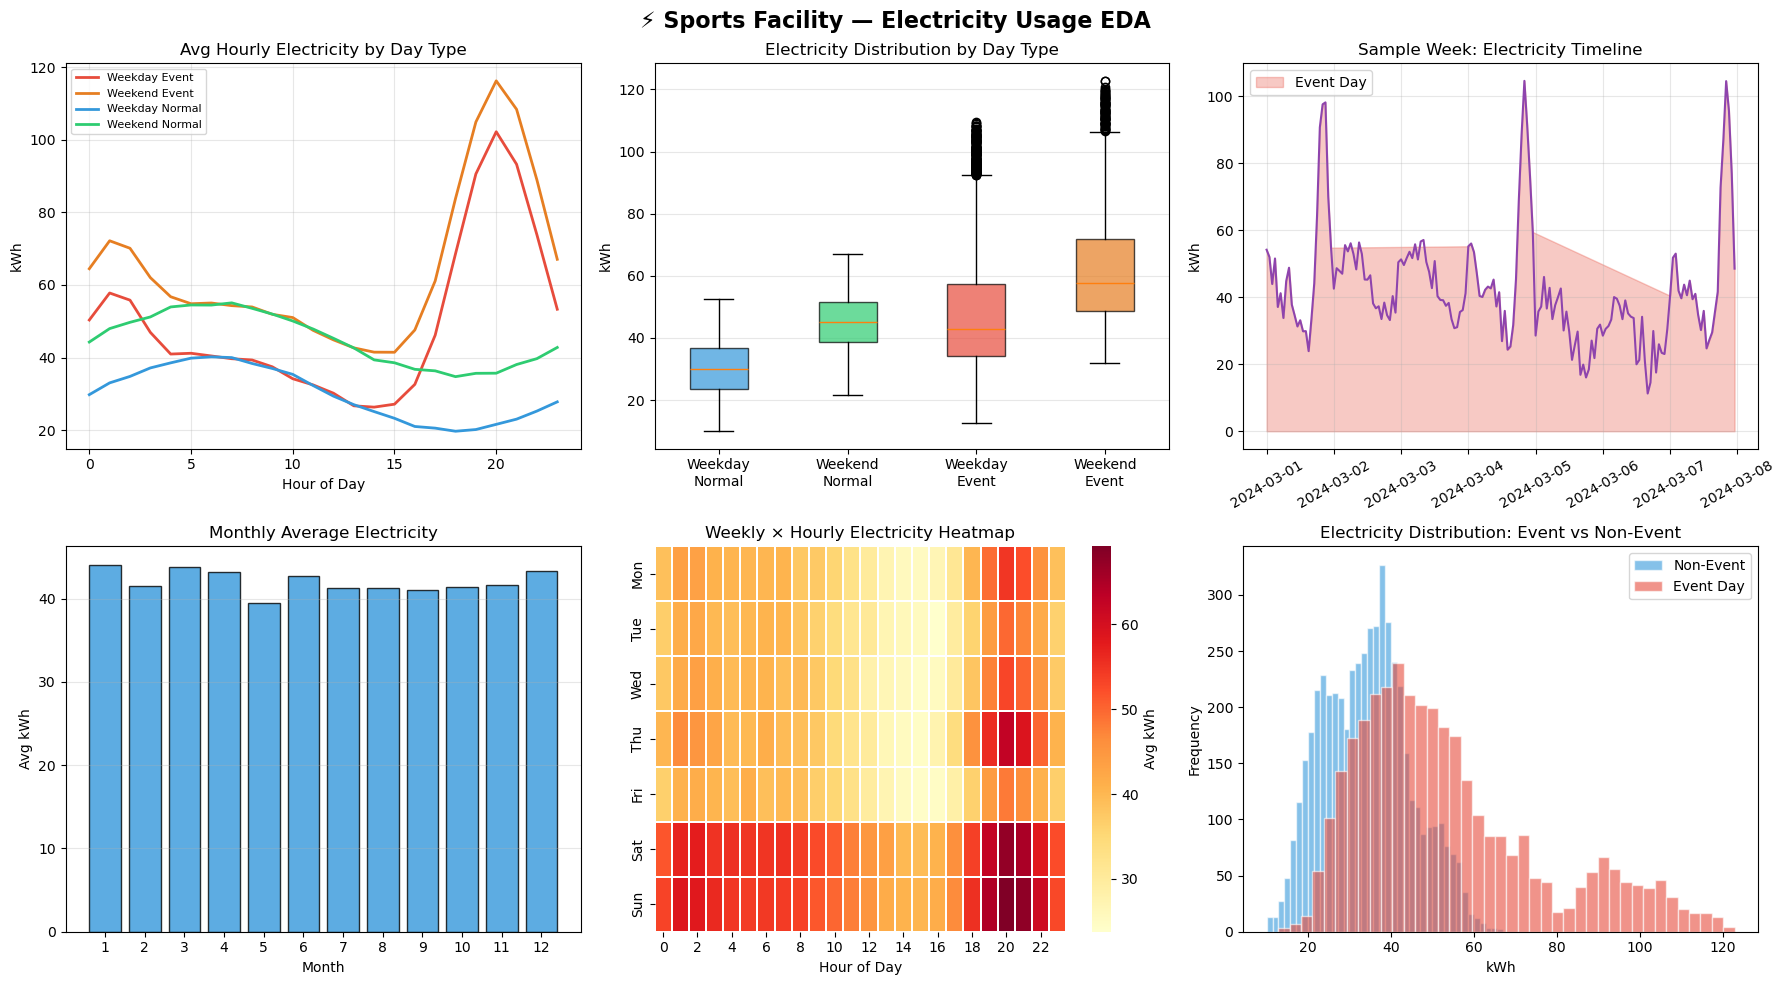

✅ EDA saved!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('⚡ Sports Facility — Electricity Usage EDA', fontsize=16, fontweight='bold')

dt_colors = {
    'Weekday Event': '#e74c3c',
    'Weekend Event': '#e67e22',
    'Weekday Normal': '#3498db',
    'Weekend Normal': '#2ecc71'
}

# 1. Hourly pattern by day type
for dtype, color in dt_colors.items():
    subset = df[df['day_type'] == dtype].groupby('hour')['electricity_kwh'].mean()
    axes[0,0].plot(subset.index, subset.values, label=dtype, color=color, linewidth=2)
axes[0,0].set_title('Avg Hourly Electricity by Day Type')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('kWh')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(alpha=0.3)

# 2. Box plot by day type
day_type_order = ['Weekday Normal', 'Weekend Normal', 'Weekday Event', 'Weekend Event']
data_boxes = [df[df['day_type']==dt]['electricity_kwh'].values for dt in day_type_order]
bp = axes[0,1].boxplot(data_boxes, labels=[d.replace(' ', '\n') for d in day_type_order],
                        patch_artist=True)
for patch, dt in zip(bp['boxes'], day_type_order):
    patch.set_facecolor(dt_colors[dt])
    patch.set_alpha(0.7)
axes[0,1].set_title('Electricity Distribution by Day Type')
axes[0,1].set_ylabel('kWh')
axes[0,1].grid(alpha=0.3, axis='y')

# 3. Sample week: event vs non-event
week_event = df[(df['timestamp'] >= '2024-03-01') & (df['timestamp'] < '2024-03-08')]
axes[0,2].plot(week_event['timestamp'], week_event['electricity_kwh'], color='#8e44ad', linewidth=1.5)
event_hours = week_event[week_event['is_event_day'] == 1]
axes[0,2].fill_between(event_hours['timestamp'], event_hours['electricity_kwh'],
                        alpha=0.3, color='#e74c3c', label='Event Day')
axes[0,2].set_title('Sample Week: Electricity Timeline')
axes[0,2].set_ylabel('kWh')
axes[0,2].legend()
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].grid(alpha=0.3)

# 4. Monthly avg
monthly = df.groupby('month')['electricity_kwh'].mean()
axes[1,0].bar(monthly.index, monthly.values, color='#3498db', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Monthly Average Electricity')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Avg kWh')
axes[1,0].set_xticks(range(1,13))
axes[1,0].grid(alpha=0.3, axis='y')

# 5. Heatmap: day of week vs hour
pivot = df.pivot_table(values='electricity_kwh', index='day_of_week', columns='hour', aggfunc='mean')
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(pivot, ax=axes[1,1], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Avg kWh'})
axes[1,1].set_title('Weekly × Hourly Electricity Heatmap')
axes[1,1].set_xlabel('Hour of Day')

# 6. Event vs non-event comparison
axes[1,2].hist(df[df['is_event_day']==0]['electricity_kwh'], bins=40, alpha=0.6,
               color='#3498db', label='Non-Event', edgecolor='white')
axes[1,2].hist(df[df['is_event_day']==1]['electricity_kwh'], bins=40, alpha=0.6,
               color='#e74c3c', label='Event Day', edgecolor='white')
axes[1,2].set_title('Electricity Distribution: Event vs Non-Event')
axes[1,2].set_xlabel('kWh')
axes[1,2].set_ylabel('Frequency')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_sports.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA saved!')

In [7]:
# Use last 24 hours to predict next hour's electricity
SEQ_LEN = 24  # lookback window (hours)

# Feature columns
feature_cols = ['electricity_kwh', 'hour', 'is_weekend', 'is_event_day']
data_array = df[feature_cols].values.astype(float)

# Scale features
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_array)

# Create sequences
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])        # past 24 hours (all features)
        y.append(data[i, 0])               # next hour electricity (index 0)
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, SEQ_LEN)

# Train / validation / test split (70/15/15)
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print(f'📐 Sequence length  : {SEQ_LEN} hours')
print(f'📌 Features         : {len(feature_cols)}')
print(f'🔢 Total sequences  : {n}')
print(f'✅ Train            : {X_train.shape}')
print(f'✅ Validation       : {X_val.shape}')
print(f'✅ Test             : {X_test.shape}')

📐 Sequence length  : 24 hours
📌 Features         : 4
🔢 Total sequences  : 8736
✅ Train            : (6115, 24, 4)
✅ Validation       : (1310, 24, 4)
✅ Test             : (1311, 24, 4)


In [9]:
# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(feature_cols))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # predict next hour kWh
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

# Train
print('\n🚀 Training LSTM...')
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
print('\n✅ Training complete!')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training LSTM...
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0205 - mae: 0.1041 - val_loss: 0.0084 - val_mae: 0.0650 - learning_rate: 0.0010
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0079 - mae: 0.0644 - val_loss: 0.0034 - val_mae: 0.0438 - learning_rate: 0.0010
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0050 - mae: 0.0522 - val_loss: 0.0036 - val_mae: 0.0442 - learning_rate: 0.0010
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0042 - mae: 0.0483 - val_loss: 0.0035 - val_mae: 0.0434 - learning_rate: 0.0010
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0040 - mae: 0.0464 - val_loss: 0.0029 - val_mae: 0.0406 - learning_rate: 0.0010
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0037 - mae: 0.0452 - val_loss: 0.0029 - val_mae: 0.0401 - learning_rate: 0.0010
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0036 - mae: 0.0445 - val_loss: 0.0028 - val_mae: 0.0396 - learning_rate: 

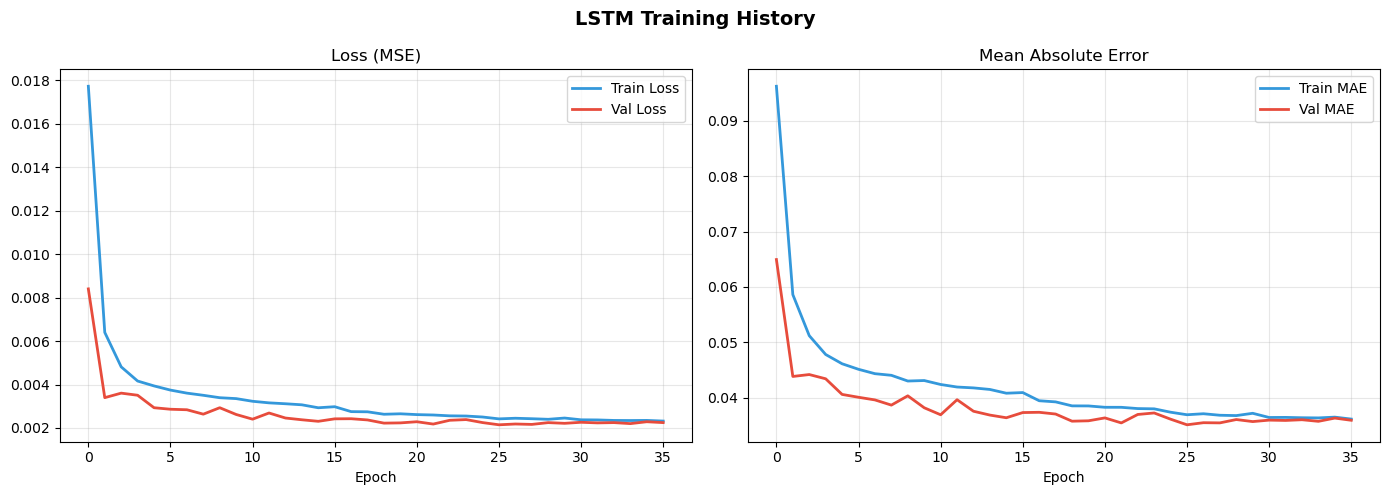

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

📋 Model Evaluation on Test Set:
   MAE  : 3.90 kWh
   RMSE : 5.12 kWh
   MAPE : 10.57%
   R²   : 0.9269


In [10]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2)
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', color='#e74c3c', linewidth=2)
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Evaluate ---
y_pred_scaled = model.predict(X_test).flatten()

# Inverse transform (only electricity column)
def inverse_electricity(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(feature_cols)))
    dummy[:, 0] = scaled_vals
    return scaler.inverse_transform(dummy)[:, 0]

y_test_actual = inverse_electricity(y_test)
y_pred_actual = inverse_electricity(y_pred_scaled)

mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print('\n📋 Model Evaluation on Test Set:')
print(f'   MAE  : {mae:.2f} kWh')
print(f'   RMSE : {rmse:.2f} kWh')
print(f'   MAPE : {mape:.2f}%')
print(f'   R²   : {r2:.4f}')

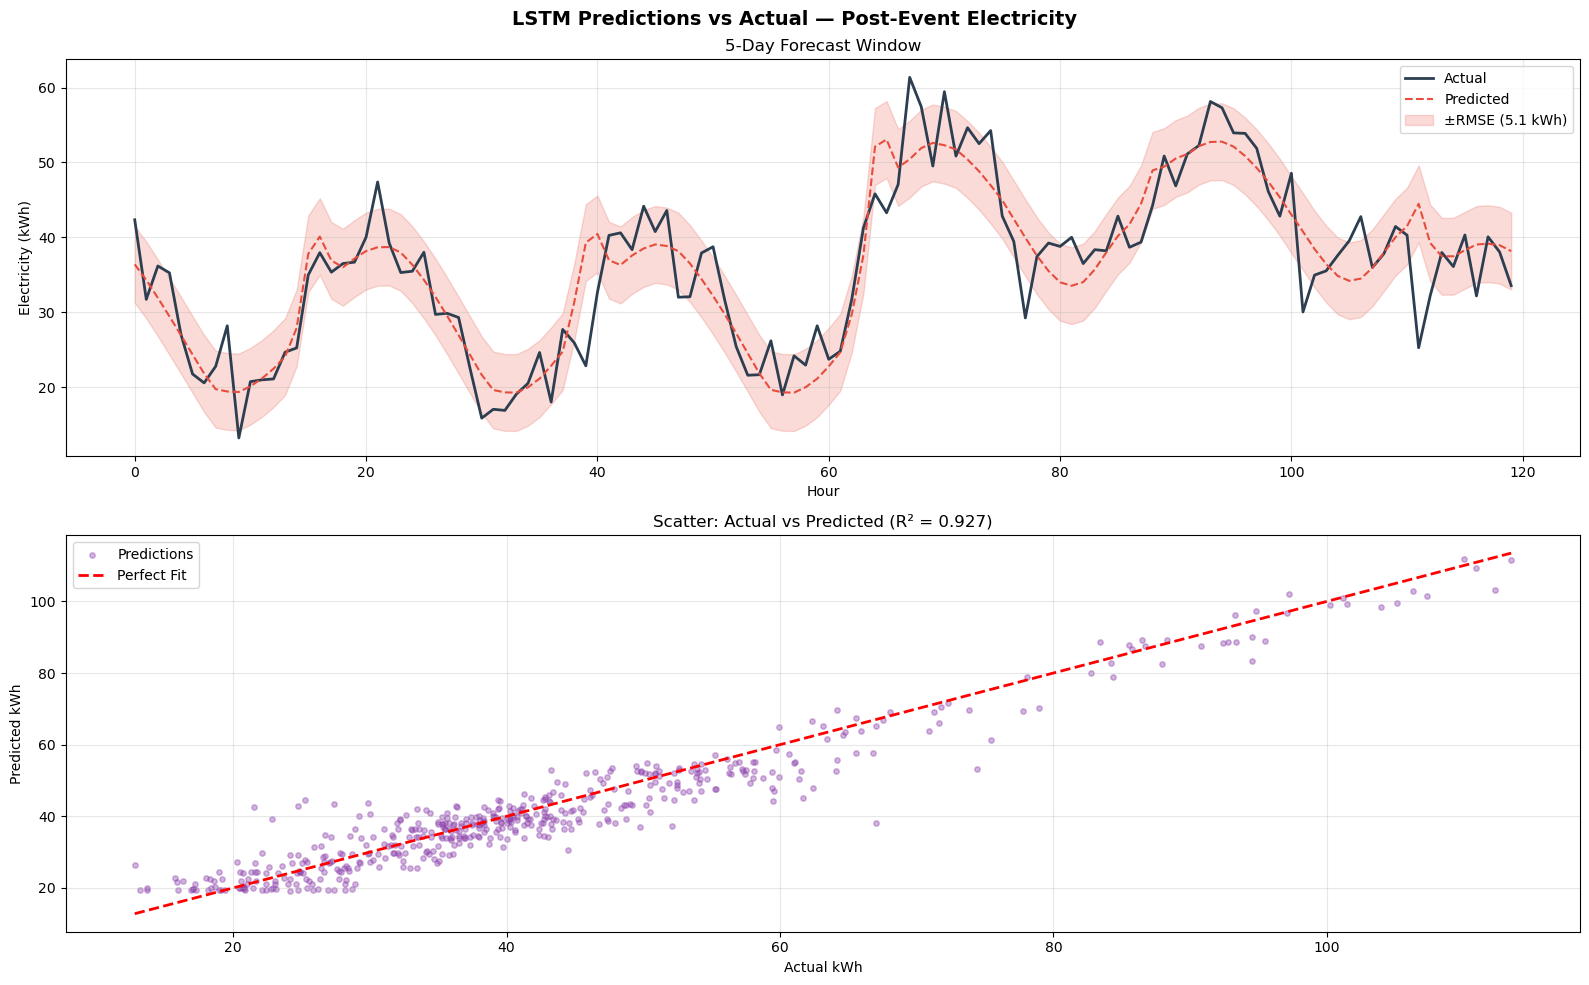

In [13]:
# Plot 5 days of predictions vs actual
n_show = 24 * 5
idx = np.arange(n_show)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('LSTM Predictions vs Actual — Post-Event Electricity', fontsize=14, fontweight='bold')

# Full line
axes[0].plot(idx, y_test_actual[:n_show], label='Actual', color='#2c3e50', linewidth=2)
axes[0].plot(idx, y_pred_actual[:n_show], label='Predicted', color='#e74c3c',
             linewidth=1.5, linestyle='--')
axes[0].fill_between(idx,
                     y_pred_actual[:n_show] - rmse,
                     y_pred_actual[:n_show] + rmse,
                     alpha=0.2, color='#e74c3c', label=f'±RMSE ({rmse:.1f} kWh)')
axes[0].set_title('5-Day Forecast Window')
axes[0].set_ylabel('Electricity (kWh)')
axes[0].set_xlabel('Hour')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter
axes[1].scatter(y_test_actual[:500], y_pred_actual[:500], alpha=0.4,
                color='#8e44ad', s=15, label='Predictions')
min_v = min(y_test_actual[:500].min(), y_pred_actual[:500].min())
max_v = max(y_test_actual[:500].max(), y_pred_actual[:500].max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Fit')
axes[1].set_title(f'Scatter: Actual vs Predicted (R² = {r2:.3f})')
axes[1].set_xlabel('Actual kWh')
axes[1].set_ylabel('Predicted kWh')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Attach predictions back to dataframe for dashboard
test_start_idx = val_end + SEQ_LEN
df_test = df.iloc[test_start_idx: test_start_idx + len(y_test_actual)].copy()
df_test['actual_kwh'] = y_test_actual
df_test['predicted_kwh'] = y_pred_actual
df_test['error'] = np.abs(df_test['actual_kwh'] - df_test['predicted_kwh'])

# ---- Build Dashboard ----
day_types = df_test['day_type'].unique().tolist()
dt_color_map = {
    'Weekday Event':   '#e74c3c',
    'Weekend Event':   '#e67e22',
    'Weekday Normal':  '#3498db',
    'Weekend Normal':  '#2ecc71'
}

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        '⚡ Actual vs Predicted by Day Type',
        '📊 Hourly Avg Electricity by Day Type',
        '🗺️ Weekly × Hourly Avg Heatmap',
        '📉 Prediction Error by Day Type'
    ],
    vertical_spacing=0.14,
    horizontal_spacing=0.10
)

# ---- Panel 1: Actual vs Predicted (dropdown by day type) ----
for dt in day_types:
    sub = df_test[df_test['day_type'] == dt].head(168)  # one week
    color = dt_color_map.get(dt, 'gray')
    fig.add_trace(go.Scatter(
        x=sub['timestamp'], y=sub['actual_kwh'],
        name=f'{dt} — Actual', mode='lines',
        line=dict(color=color, width=2),
        legendgroup=dt
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=sub['timestamp'], y=sub['predicted_kwh'],
        name=f'{dt} — Pred', mode='lines',
        line=dict(color=color, width=1.5, dash='dot'),
        legendgroup=dt
    ), row=1, col=1)

# ---- Panel 2: Hourly avg by day type ----
for dt in day_types:
    sub = df_test[df_test['day_type'] == dt].groupby('hour')['actual_kwh'].mean().reset_index()
    fig.add_trace(go.Scatter(
        x=sub['hour'], y=sub['actual_kwh'],
        name=dt, mode='lines+markers',
        line=dict(color=dt_color_map.get(dt, 'gray'), width=2),
        marker=dict(size=6),
        showlegend=False
    ), row=1, col=2)

# ---- Panel 3: Heatmap ----
pivot = df_test.pivot_table(
    values='actual_kwh', index='day_of_week', columns='hour', aggfunc='mean'
)
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fig.add_trace(go.Heatmap(
    z=pivot.values,
    x=[str(h) for h in pivot.columns],
    y=pivot.index.tolist(),
    colorscale='YlOrRd',
    colorbar=dict(title='kWh', x=0.46, len=0.45),
    showscale=True
), row=2, col=1)

# ---- Panel 4: Error boxplot by day type ----
for dt in day_types:
    sub = df_test[df_test['day_type'] == dt]
    fig.add_trace(go.Box(
        y=sub['error'],
        name=dt,
        marker_color=dt_color_map.get(dt, 'gray'),
        showlegend=False
    ), row=2, col=2)

# ---- Dropdown: filter by day type ----
buttons = []
all_traces = len(fig.data)

# "All" button
buttons.append(dict(
    label='All Day Types',
    method='update',
    args=[{'visible': [True] * all_traces}]
))

# Per day type buttons (show only panel 1 & 2 traces for that type)
panel1_traces_per_dt = 2  # actual + pred per day type
for i, dt in enumerate(day_types):
    visible = [False] * all_traces
    # Panel 1: 2 traces per day type
    base = i * panel1_traces_per_dt
    visible[base] = True
    visible[base + 1] = True
    # Always show panels 3 & 4 (heatmap starts after panel1+panel2 traces)
    n_p1 = len(day_types) * 2
    n_p2 = len(day_types)
    for j in range(n_p1 + n_p2, all_traces):
        visible[j] = True
    buttons.append(dict(
        label=dt,
        method='update',
        args=[{'visible': visible}]
    ))

fig.update_layout(
    title=dict(
        text='⚡ Sports Facility Night Usage — LSTM Electricity Dashboard',
        font=dict(size=18), x=0.5
    ),
    height=850,
    template='plotly_white',
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.01, xanchor='left',
        y=1.12, yanchor='top',
        bgcolor='#ecf0f1',
        bordercolor='#bdc3c7'
    )],
    annotations=[dict(
        text='Filter by Day Type →', x=0.0, xref='paper',
        y=1.15, yref='paper', showarrow=False, font=dict(size=12)
    )],
    legend=dict(x=1.01, y=1)
)

fig.update_xaxes(title_text='Hour of Day', row=1, col=2)
fig.update_yaxes(title_text='Avg kWh', row=1, col=2)
fig.update_xaxes(title_text='Hour', row=2, col=1)
fig.update_yaxes(title_text='Abs Error (kWh)', row=2, col=2)

fig.write_html('sports_dashboard.html')
fig.show()
print('✅ Interactive dashboard saved as sports_dashboard.html')